# NCAA tournament forecasting
## From feature expansion to margin supervision
**Alvaro Mendizabal · September 2026 research release**

This executed notebook replays aggregate evidence from completed AWS experiments. It performs no model fitting, downloads, cloud calls, or submissions. The scored incumbent and the unsubmitted research challenger are different systems.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if not (root / 'portfolio').is_dir():
    root = root.parent
sys.path.insert(0, str(root / 'portfolio'))
from current_research import load_evidence, chart
import pandas as pd
from IPython.display import display
e = load_evidence()
r = e['robustness']
display(pd.DataFrame([{'Evidence': 'Observed late Kaggle submission', 'Brier': e['scored']['incumbent'], 'Status': 'Scored'}, {'Evidence': 'Historical margin blend: men, 189 games', 'Brier': r['pooled']['margin'], 'Status': 'Unsubmitted; build review only'}]))

,Evidence,Brier,Status
0,Observed late Kaggle submission,0.109869,Scored
1,"Historical margin blend: men, 189 games",0.177465,Unsubmitted; build review only


## 1. What has actually been scored?
The two-feature men’s incumbent achieved **0.1098691** in a late submission. The first-place author reports **0.1097454** over 126 games. This is a numerical reference, not a claim of original placement or exact score-scope equivalence. The margin challenger has no Kaggle score. These numbers must not be mixed with historical Brier.

,Incumbent improvement,Numerical gap to benchmark
0,0.000043,0.000124


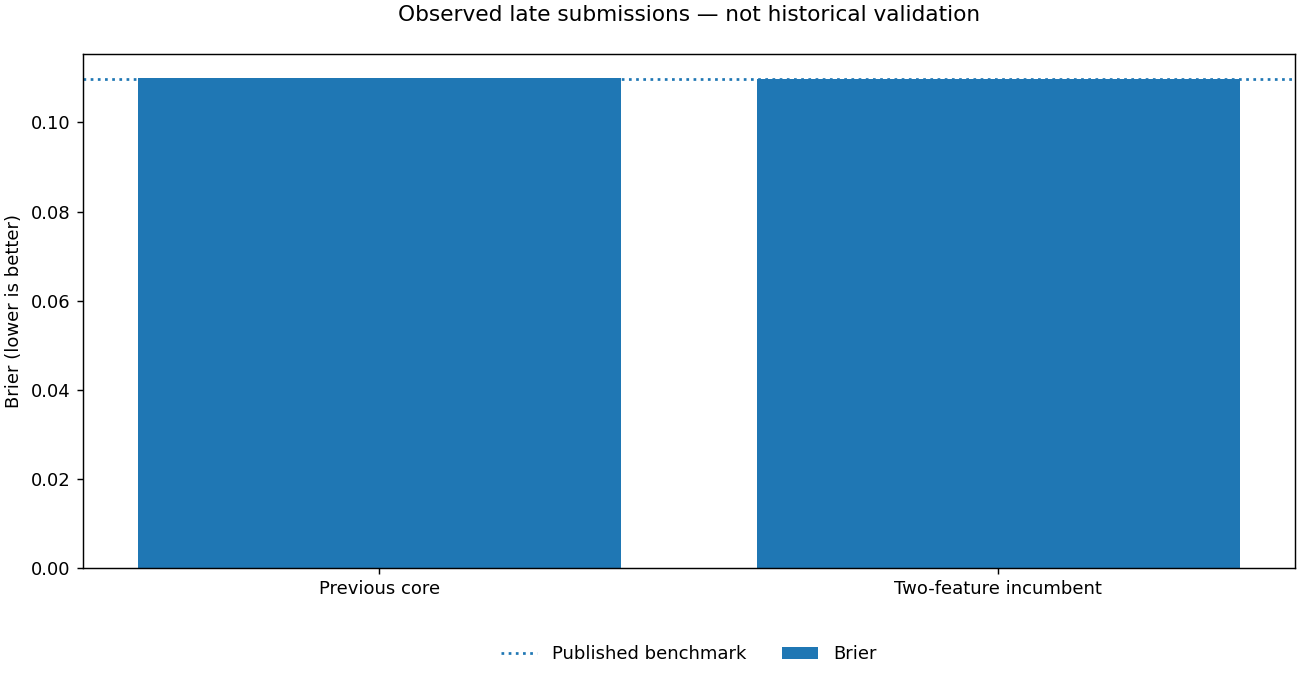

In [2]:
s = e['scored']
display(pd.DataFrame([{'Incumbent improvement': s['previous']-s['incumbent'], 'Numerical gap to benchmark': s['incumbent']-s['published_benchmark']}]))
chart('scored', 'Observed late submissions — not historical validation', ['Previous core', 'Two-feature incumbent'], {'Brier': [s['previous'], s['incumbent']]}, 'Brier (lower is better)', s['published_benchmark'])

## 2. Why change the training target?
Adding a full auxiliary feature bundle, compressing residual variation, selecting small subsets chronologically, and correcting frozen-core errors did not produce a promotable system. Instead of repeating those searches, the next controlled comparison changed the supervised target from signed win/loss to signed point margin.

The compact core uses **seed difference and Harry-rating difference**. The auxiliary model uses those plus **31 existing basketball feature differences**. Both targets use the same 33 features, XGBoost squared error, depth-three trees, regularization and sigmoid calibration. Only the target changes. A one-point and a 25-point win no longer provide identical supervision. This mechanism was tested; it is not assumed to be superior.

,experiment,core,candidate,gain,decision
0,Full feature bundle,0.186664,0.189996,-0.003332,Rejected
1,Residual PCA bundle,0.186664,0.189000,-0.002336,Rejected
2,Nested subset selection,0.186664,0.187789,-0.001125,Rejected
3,Frozen-core feature correction,0.186664,0.187130,-0.000466,Rejected
4,Fixed 25% rich margin blend,0.186664,0.185529,0.001135,Advanced to robustness


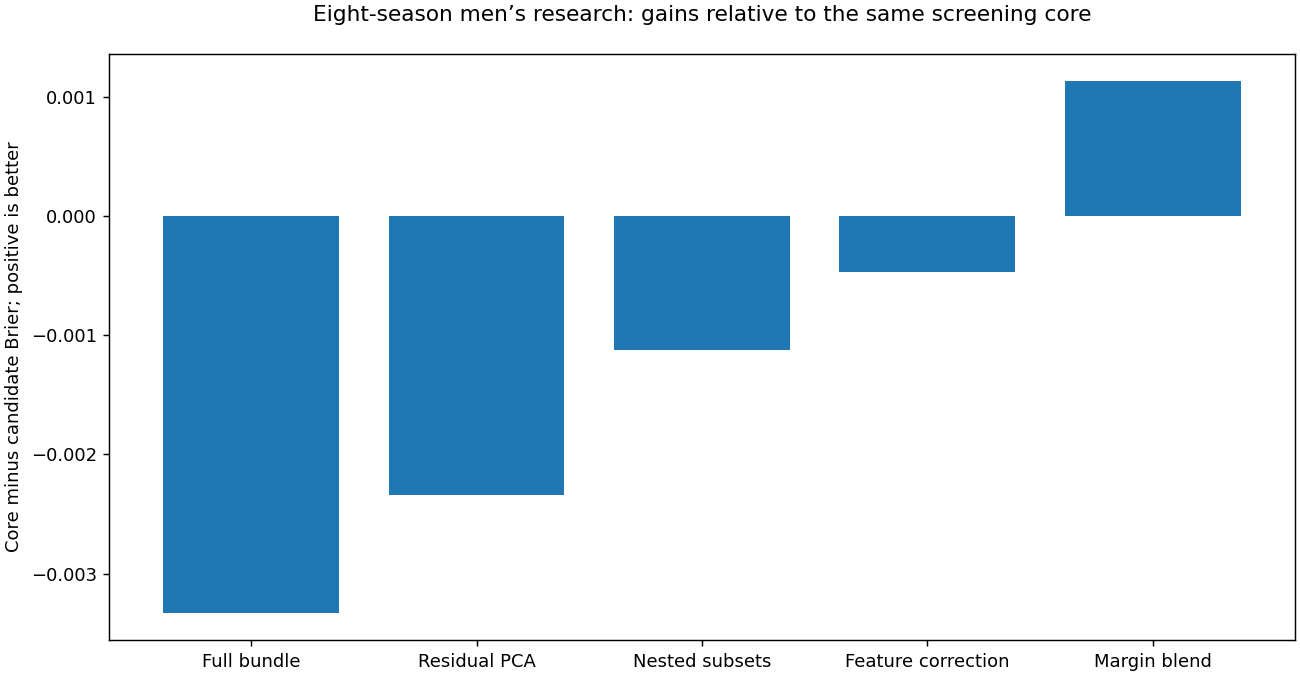

In [3]:
screen = pd.DataFrame(e['screen']['rows'])
screen['gain'] = screen['core'] - screen['candidate']
display(screen[['experiment','core','candidate','gain','decision']])
chart('screen', 'Eight-season men’s research: gains relative to the same screening core', ['Full bundle','Residual PCA','Nested subsets','Feature correction','Margin blend'], {'Brier reduction': screen['gain'].tolist()}, 'Core minus candidate Brier; positive is better')

These five summaries concern the same 503-game men’s screen, but reused development years and sequentially chosen hypotheses. They are not independent trials. The women’s subset experiment was rejected after four years; its incomplete result is not combined with this eight-year chart. Negative results narrowed the next question rather than being hidden.

## 3. Does the exact candidate survive a fuller ensemble?
For each outer year, train only on earlier seasons. Leave out each earlier season in turn, repeat for three fixed seeds, calibrate on inner held-out scores, and average the forecasts. Both margin and binary targets are run as a matched control.

**Frozen prediction rule:** 0.75 × retained core probability + 0.25 × auxiliary probability. No weight search, favorable-seed selection, core retraining, or changes to women’s predictions. The three years contain 63 main-bracket games each.

,core,binary blend,margin blend,gain vs core,gain vs matched binary
0,0.179505,0.177882,0.177465,0.00204,0.000417


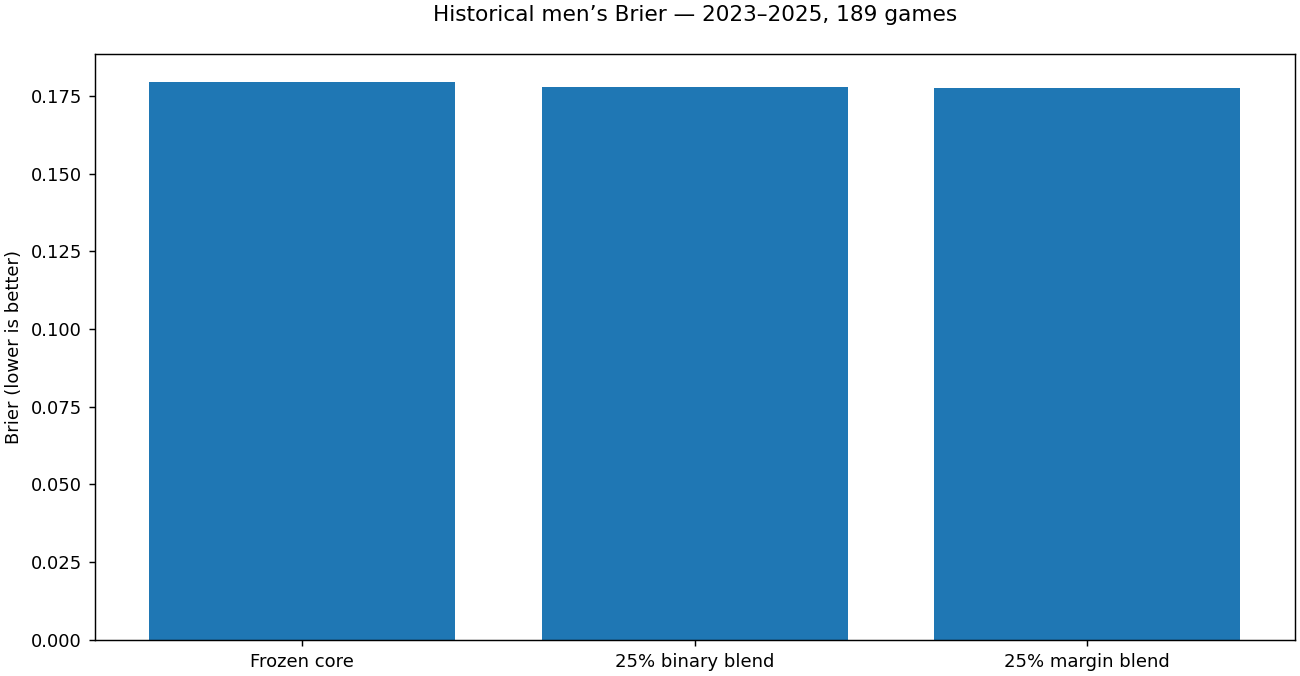

In [4]:
pooled = r['pooled']
display(pd.DataFrame([{'core': pooled['core'], 'binary blend': pooled['binary'], 'margin blend': pooled['margin'], 'gain vs core': pooled['core']-pooled['margin'], 'gain vs matched binary': pooled['binary']-pooled['margin']}]))
chart('pooled', 'Historical men’s Brier — 2023–2025, 189 games', ['Frozen core','25% binary blend','25% margin blend'], {'Brier': [pooled['core'],pooled['binary'],pooled['margin']]}, 'Brier (lower is better)')

,year,games,core,binary,margin
0,2023,63,0.209928,0.208175,0.207977
1,2024,63,0.188468,0.187603,0.186258
2,2025,63,0.140118,0.137867,0.138159


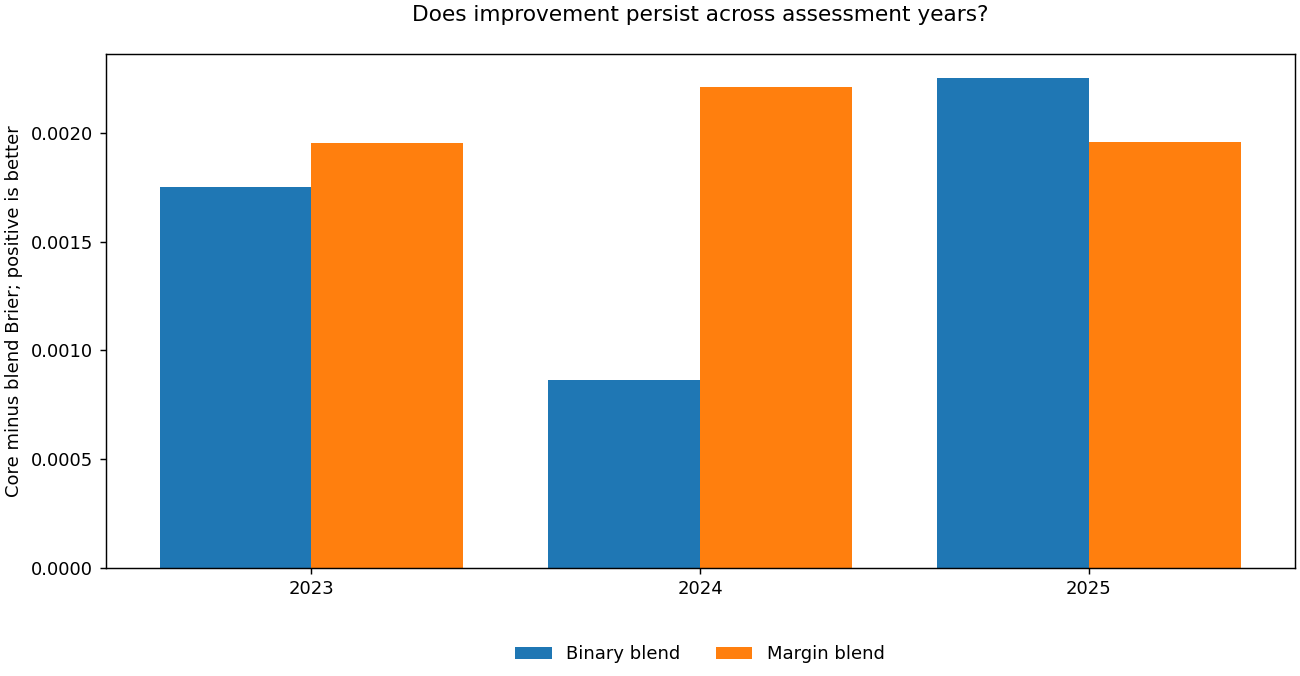

In [5]:
years = pd.DataFrame(r['rows'])
display(years)
chart('years', 'Does improvement persist across assessment years?', years['year'].astype(str).tolist(), {'Binary blend': (years['core']-years['binary']).tolist(), 'Margin blend': (years['core']-years['margin']).tolist()}, 'Core minus blend Brier; positive is better')

The margin blend improves on the core in all three years. It beats the matched binary blend in **two of three**, not all three: the binary blend is better in 2025. The pooled objective advantage is approximately **0.0004168 Brier**. This distinction prevents claiming more than the controlled comparison supports.

,seed,brier,gain
0,20260921,0.177363,0.002141
1,20260922,0.177548,0.001957
2,20260923,0.177485,0.002020


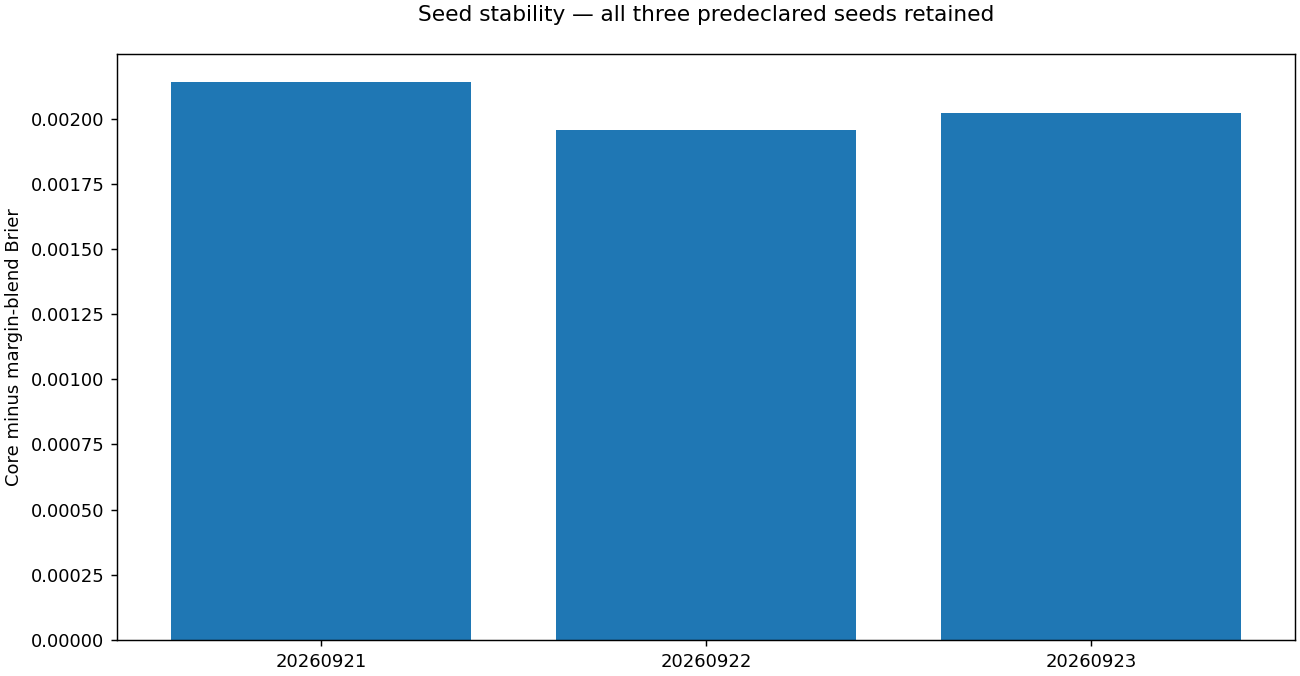

In [6]:
seed = pd.DataFrame(r['seeds'])
seed['gain'] = pooled['core'] - seed['brier']
display(seed)
chart('seeds', 'Seed stability — all three predeclared seeds retained', seed['seed'].astype(str).tolist(), {'Brier reduction': seed['gain'].tolist()}, 'Core minus margin-blend Brier')

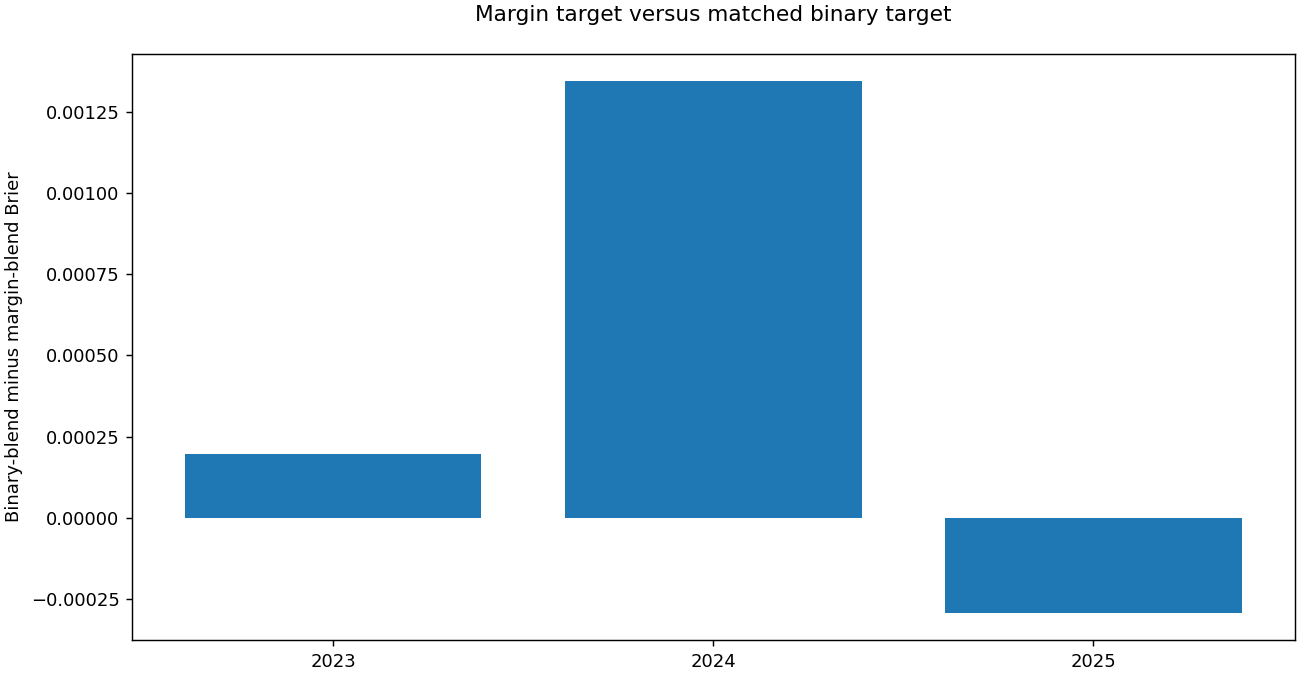

In [7]:
chart('ablation', 'Margin target versus matched binary target', years['year'].astype(str).tolist(), {'Margin advantage': (years['binary']-years['margin']).tolist()}, 'Binary-blend minus margin-blend Brier')

## 4. Decision, uncertainty and cost
The recorded decision is **CANDIDATE_BUILD_REVIEW**, not production promotion. The run completed 360 tree fits in about 76 seconds overall and passed 61 regression tests. Source and checkpoint receipts were preserved; no feature rebuild or submission was performed. Publication itself adds no training.

The outer years were excluded from fitting, but have already been used repeatedly during project development. The earlier margin screen selected this proposal on overlapping years. Three random seeds do not supply three independent outcome sets. Inner held-out scores are used for both early stopping and calibration. Conditional season-bootstrap results are not selection-adjusted evidence of a future win.

In [8]:
display(pd.DataFrame([{'Check': k, 'Passed': v} for k,v in r['checks'].items()]))
print('Decision:', r['decision'])
print('Candidate Kaggle score:', r['new_kaggle_score'])
print('New model fits performed by this report:', 0)

,Check,Passed
0,all_tournament_guard,True
1,at_least_two_seasons,True
2,conditional_support,True
3,every_predeclared_seed_nonnegative,True
4,gain_over_strong_core,True
5,margin_beats_matched_binary,True
6,worst_season_guard,True


Decision: CANDIDATE_BUILD_REVIEW
Candidate Kaggle score: None
New model fits performed by this report: 0


## 5. Reproducibility and the next boundary
Committed aggregate evidence includes source-return SHA-256 values, the scored candidate identity, run ID, policy, per-year and per-seed metrics. The report validates arithmetic before rendering. Raw competition records, per-game predictions, fitted models, credentials, machine-specific paths and environments are intentionally absent.

Re-executing this notebook reproduces the published tables and plots, **not** model training. The broader source repository and AWS retain their distinct purposes. The next modeling milestone is one frozen 2026 candidate build with schema, probability, row-identity and protected-women checks, followed by separately authorized scoring.

See `reports/current_research/evidence.json` and `docs/current_research.md` for provenance and the source-to-publication boundary. The first-place mechanism is attributed to Harrison Horan’s public writeup; this margin extension is not an exact winning-solution reproduction.

In [9]:
print('REPORT_COMPLETE — aggregate evidence only; no training or submission')

REPORT_COMPLETE — aggregate evidence only; no training or submission
